**Program No. 20.  >> Firewall Log Visualization**

**Objective:** To identify suspicious traffic using visualization.

**Tasks:**
- Visualize firewall log data
- Identify suspicious traffic patterns

**Outcome:** Students will detect anomalies using visual analysis.


**Step 1:** Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Step 2:** Load Dataset

In [2]:
df = pd.read_csv("firewall_logs.csv")

# Clean columns
df.columns = df.columns.str.strip()

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (300, 8)
             Timestamp       Source_IP  Destination_IP Protocol  Source_Port  \
0  2025-01-25 21:37:13   35.118.190.14   44.207.46.184      UDP        25152   
1  2025-01-15 12:25:33  239.197.64.143   16.187.153.91      TCP        64772   
2  2025-01-15 02:26:55  162.58.193.198  154.214.181.40      UDP        24505   
3  2025-01-16 08:51:48  36.144.120.234  109.64.209.130      TCP        64576   
4  2025-01-30 16:59:33  167.162.40.243  115.93.100.100      UDP        16537   

   Destination_Port Action Threat_Level  
0                80  BLOCK       Medium  
1               443  BLOCK          Low  
2               443  BLOCK          Low  
3                80  BLOCK         High  
4                22  BLOCK         High  


**Visualization 1** — ALLOW vs BLOCK Traffic

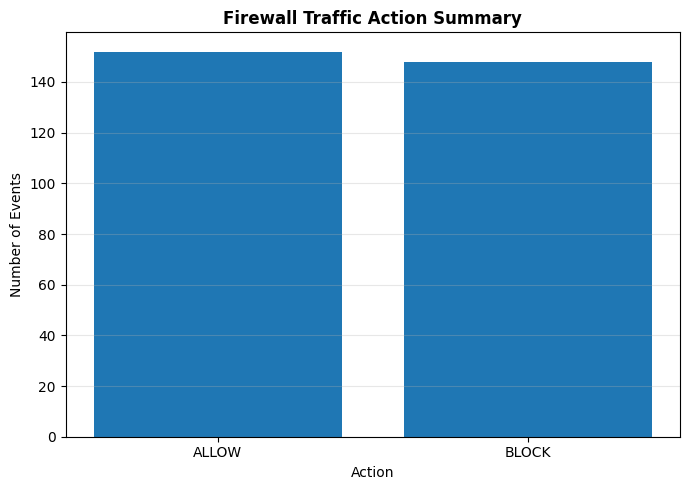

In [3]:
action_count = df["Action"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(action_count.index, action_count.values)

plt.title("Firewall Traffic Action Summary",
          fontweight="bold")

plt.xlabel("Action")
plt.ylabel("Number of Events")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Visualization 2** — Threat Level Distribution

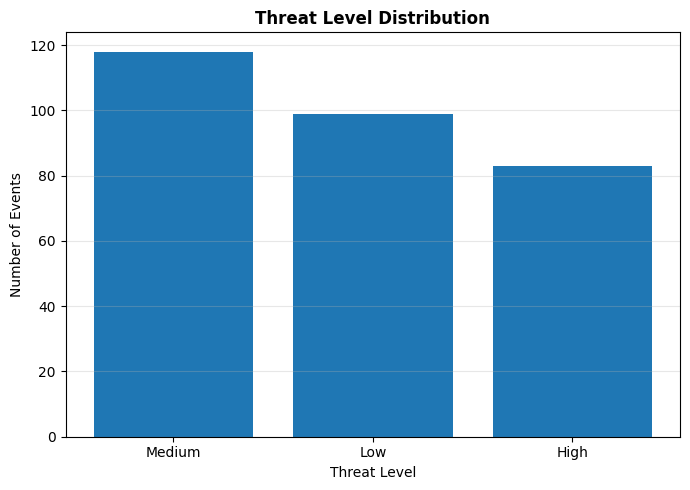

In [4]:
threat_count = df["Threat_Level"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(threat_count.index, threat_count.values)

plt.title("Threat Level Distribution",
          fontweight="bold")

plt.xlabel("Threat Level")
plt.ylabel("Number of Events")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Visualization 3** — Suspicious Destination Ports

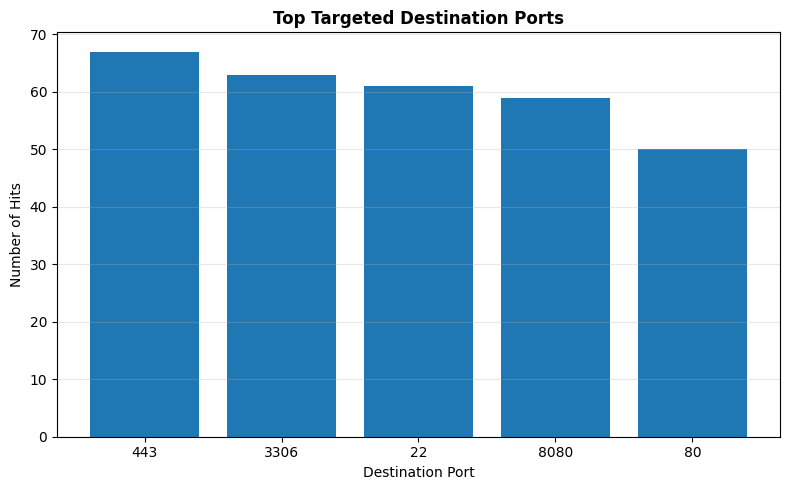

In [5]:
top_ports = df["Destination_Port"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.bar(top_ports.index.astype(str), top_ports.values)

plt.title("Top Targeted Destination Ports",
          fontweight="bold")

plt.xlabel("Destination Port")
plt.ylabel("Number of Hits")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Visualization 4** — BLOCKED Traffic by Protocol

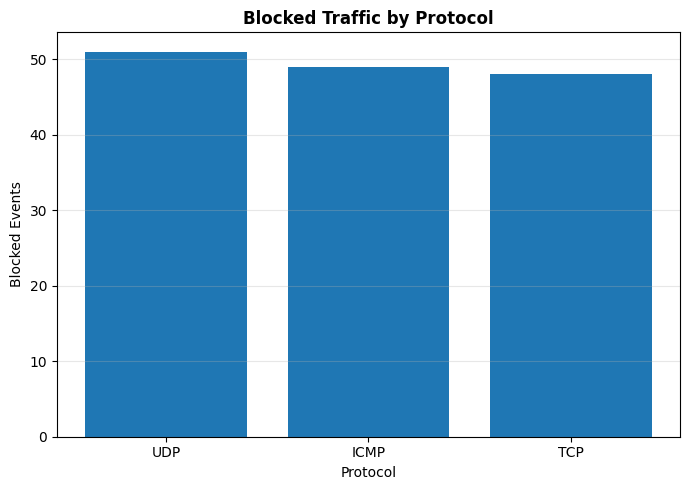

In [6]:
blocked = df[df["Action"] == "BLOCK"]

protocol_block = blocked["Protocol"].value_counts()

plt.figure(figsize=(7,5))
plt.bar(protocol_block.index, protocol_block.values)

plt.title("Blocked Traffic by Protocol",
          fontweight="bold")

plt.xlabel("Protocol")
plt.ylabel("Blocked Events")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

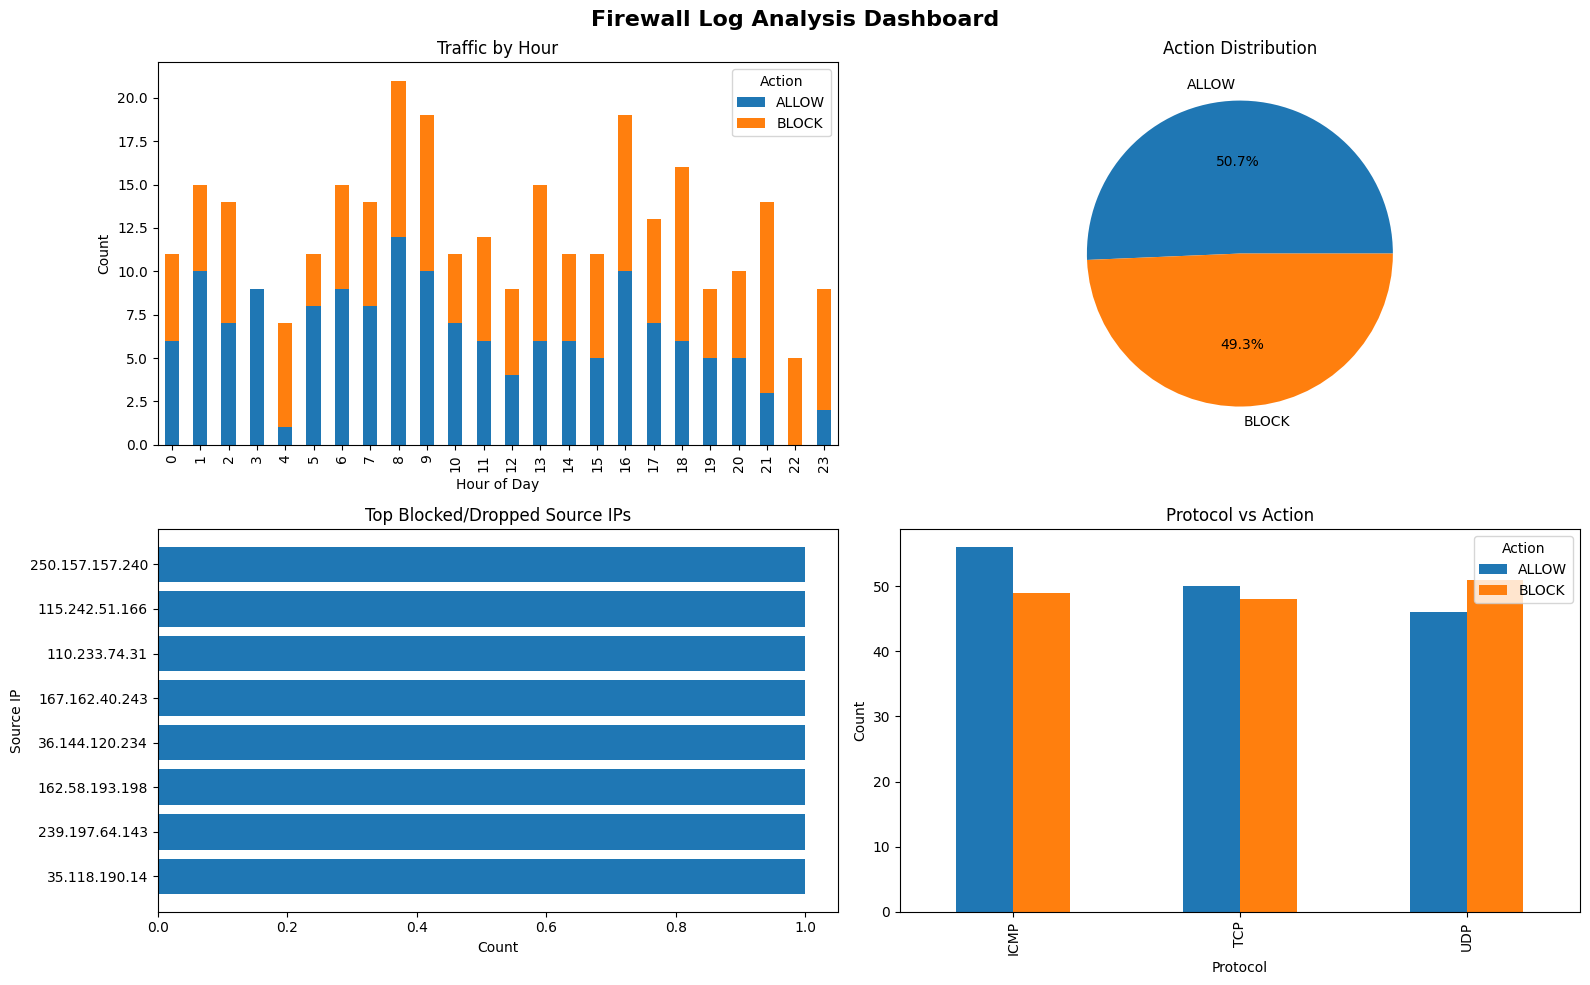

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("firewall_logs.csv")
df.columns = df.columns.str.strip()

# Convert timestamp to datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Extract hour
df["Hour"] = df["Timestamp"].dt.hour

# Create figure
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Firewall Log Analysis Dashboard", fontsize=16, fontweight="bold")

# --------------------------------------------------
# 1️⃣ Traffic by Hour (Stacked Bar)
# --------------------------------------------------
hourly_action = df.groupby(["Hour", "Action"]).size().unstack(fill_value=0)

hourly_action.plot(
    kind="bar",
    stacked=True,
    ax=axs[0,0]
)

axs[0,0].set_title("Traffic by Hour")
axs[0,0].set_xlabel("Hour of Day")
axs[0,0].set_ylabel("Count")
axs[0,0].legend(title="Action")

# --------------------------------------------------
# 2️⃣ Action Distribution (Pie Chart)
# --------------------------------------------------
action_counts = df["Action"].value_counts()

axs[0,1].pie(
    action_counts,
    labels=action_counts.index,
    autopct="%1.1f%%"
)

axs[0,1].set_title("Action Distribution")

# --------------------------------------------------
# 3️⃣ Top Blocked/Dropped Source IPs
# --------------------------------------------------
suspicious = df[df["Action"].isin(["BLOCK", "DROP"])]

top_ips = suspicious["Source_IP"].value_counts().head(8)

axs[1,0].barh(top_ips.index, top_ips.values)
axs[1,0].set_title("Top Blocked/Dropped Source IPs")
axs[1,0].set_xlabel("Count")
axs[1,0].set_ylabel("Source IP")

# --------------------------------------------------
# 4️⃣ Protocol vs Action
# --------------------------------------------------
protocol_action = df.groupby(["Protocol", "Action"]).size().unstack(fill_value=0)

protocol_action.plot(
    kind="bar",
    ax=axs[1,1]
)

axs[1,1].set_title("Protocol vs Action")
axs[1,1].set_xlabel("Protocol")
axs[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()